## 1. Introduction to the Butler for LSST–VISTA XMM data

This notebook is a simple introduction to the Butler on UK RSP for the
`lsst-ir-fusion` repository.

The goal is to learn how to:

- open the Butler,
- inspect collections and dataset types,
- identify VIDEO/XMM collections,
- find the tract and patch for a sky position,
- query available coadds for that patch,
- retrieve and display one example image.


### 1.1 Imports

We start with a few standard Python packages and the LSST Butler and display tools.

In [1]:
# General scientific Python packages
import numpy as np
import matplotlib.pyplot as plt

# Butler and LSST geometry/display packages
import lsst.daf.butler as dafButler
import lsst.geom
import lsst.afw.display as afwDisplay

### 1.2 Initialize the Butler

On UK RSP, the LSST–VISTA Butler can be opened by its repository label.
This gives us access to the registry and to the datasets stored in the repo.

In [2]:
butler = dafButler.Butler("lsst-ir-fusion")
registry = butler.registry

### 1.3 Find the main collections

The Butler registry stores the collections available in this repository.

Here we print all collections, then automatically pick the two science collections we will use in the rest of the notebook:

- the coadd detection collection
- the multi-visit measurement collection

In [3]:
# Print available collections and choose the main science collections

all_collections = sorted(registry.queryCollections())

print(f"Number of collections found: {len(all_collections)}")
print("\nAvailable collections:")
for c in all_collections:
    print(" ", c)

coadd_collection = next(c for c in all_collections if "videoCoaddDetect" in c)
multivisit_collection = next(c for c in all_collections if "videoMultiVisit" in c)

print("\nSelected collections:")
print("coadd_collection      =", coadd_collection)
print("multivisit_collection =", multivisit_collection)

Number of collections found: 3

Available collections:
  skymaps
  u/dc-park2/DRP/videoCoaddDetect/20260116T115441Z
  u/dc-park2/DRP/videoMultiVisit/20260212T193420Z

Selected collections:
coadd_collection      = u/dc-park2/DRP/videoCoaddDetect/20260116T115441Z
multivisit_collection = u/dc-park2/DRP/videoMultiVisit/20260212T193420Z


### 1.4 Dataset types

Collections contain datasets, and each dataset belongs to a dataset type.

Looking through dataset types is a useful way to understand what kind of products the repo stores.

In [4]:
dataset_types = sorted(registry.queryDatasetTypes(), key=lambda dt: dt.name)

print(f"Number of dataset types found: {len(dataset_types)}")
print("\nDataset type names:")
for dt in dataset_types:
    print(" ", dt.name)

Number of dataset types found: 4

Dataset type names:
  deepCoadd_calexp
  deepCoadd_forced_src
  deepCoadd_meas
  skyMap


We can inspect one dataset type in more detail.
Here we use `deepCoadd_calexp`, which is one of the main image products.

In [5]:
dt = registry.getDatasetType("deepCoadd_calexp")
print("Name         :", dt.name)
print("Dimensions   :", dt.dimensions)
print("Storage class:", dt.storageClass)


Name         : deepCoadd_calexp
Dimensions   : {band, skymap, tract, patch}
Storage class: ExposureF


### 1.5 Dimensions and data IDs

The Butler organizes data using dimensions such as tract, patch, band, and skymap.

It is often helpful to inspect the available fields for one dimension. Below we look at the patch definition.


In [6]:
print(registry.dimensions["patch"].RecordClass.fields)

patch: 
  skymap: str
  tract: int
  id: int
  cell_x: int
  cell_y: int
  region: lsst.sphgeom.Region


### 1.6 Inspect available skymaps

To convert sky coordinates into tract and patch, we need a skymap.

The `skymaps` collection usually stores the available skymap definitions.


In [7]:
skyMap_refs = list(registry.queryDatasets("skyMap", collections="skymaps"))

print("Available skyMap dataset refs:")
for ref in skyMap_refs:
    print(" ", dict(ref.dataId.mapping))

Available skyMap dataset refs:
  {'skymap': 'hscPdr2'}


For the examples below, we select one skymap name from the available refs.
If only one skymap is present, this cell will pick it automatically.

In [8]:
if not skyMap_refs:
    raise RuntimeError("No skyMap dataset found in the 'skymaps' collection.")

skymap_name = skyMap_refs[0].dataId["skymap"]
print("Using skymap:", skymap_name)

Using skymap: hscPdr2


### 1.7 Example sky position in the XMM field

As a simple example, we use the position of JKCS 041 in the XMM-LSS region.

You can replace these coordinates later with any target you want to inspect.

In [9]:
my_ra_deg = 36.687745
my_dec_deg = -4.6940845

my_spherePoint = lsst.geom.SpherePoint(
    my_ra_deg * lsst.geom.degrees,
    my_dec_deg * lsst.geom.degrees,
)

print("SpherePoint:", my_spherePoint)

SpherePoint: (36.6877450000, -4.6940845000)


### 1.8 Find tract/patch based on sky position


In [10]:
# Convert sky position to tract and patch

skymap_name = "hscPdr2"
skymap = butler.get("skyMap", skymap=skymap_name, collections="skymaps")

tract_info = skymap.findTract(my_spherePoint)
patch_info = tract_info.findPatch(my_spherePoint)

my_tract = tract_info.getId()
my_patch = patch_info.getSequentialIndex()

print("skymap:", skymap_name)
print("tract :", my_tract)
print("patch :", my_patch)

skymap: hscPdr2
tract : 8525
patch : 70


### 1.9 Query available coadds for this tract and patch

Before retrieving an image, it is good practice to ask the registry what is actually available.

This keeps the notebook flexible and makes it easier to adapt when collections are updated.

In [11]:
if coadd_collection is None:
    raise RuntimeError("No matching videoCoaddDetect collection was found.")

coadd_refs = list(
    registry.queryDatasets(
        "deepCoadd_calexp",
        dataId={"tract": my_tract, "patch": my_patch, "skymap": skymap_name},
        collections=coadd_collection,
    )
)

print(f"Number of deepCoadd_calexp refs found: {len(coadd_refs)}")
for ref in sorted(coadd_refs, key=lambda r: str(r.dataId)):
    print(dict(ref.dataId.mapping))

Number of deepCoadd_calexp refs found: 5
{'band': 'H', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'J', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'K', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'Y', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'Z', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}


The result above shows which bands exist for this tract and patch in the selected coadd collection.
We can extract the available band names directly from the returned refs.


In [12]:
available_bands = sorted({ref.dataId["band"] for ref in coadd_refs})

print("Available bands:", available_bands)

Available bands: ['H', 'J', 'K', 'Y', 'Z']


### 1.10 Retrieve one coadd image

For this notebook, we choose one band and load the corresponding coadd image.

If `K` exists we use it, otherwise we fall back to the first available band.


In [13]:
if not available_bands:
    raise RuntimeError("No coadd image found for this tract/patch.")

band = "K" if "K" in available_bands else available_bands[0]
print("Selected band:", band)

my_deepCoadd = butler.get(
    "deepCoadd_calexp.image",
    band=band,
    tract=my_tract,
    patch=my_patch,
    skymap=skymap_name,
    collections=coadd_collection,
)


Selected band: K


### 1.11 Display the image

A simple way to display LSST image products in notebooks is `afwDisplay`.
Here we use the matplotlib backend and a standard asinh/zscale display.


In [14]:
afwDisplay.setDefaultBackend("matplotlib")

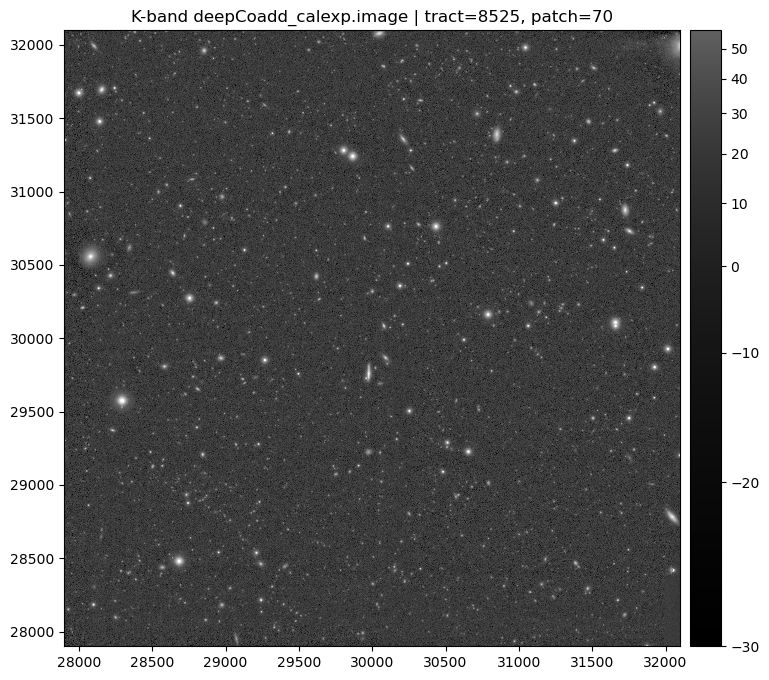

In [15]:
fig = plt.figure(figsize=(10, 8))
afw_display = afwDisplay.Display(frame=1)
afw_display.scale("asinh", "zscale")
afw_display.mtv(my_deepCoadd)
plt.gca().axis("on")
plt.title(f"{band}-band deepCoadd_calexp.image | tract={my_tract}, patch={my_patch}")
plt.show()

### 1.12 Check whether a multiband catalog exists for the same patch


In [16]:
if multivisit_collection is None:
    print("No matching videoMultiVisit collection was found.")
else:
    forced_refs = list(
        registry.queryDatasets(
            "deepCoadd_forced_src",
            dataId={"tract": my_tract, "patch": my_patch, "skymap": skymap_name},
            collections=multivisit_collection,
        )
    )

    print(f"Number of deepCoadd_forced_src refs found: {len(forced_refs)}")
    for ref in sorted(forced_refs, key=lambda r: str(r.dataId)):
        print(dict(ref.dataId.mapping))

Number of deepCoadd_forced_src refs found: 10
{'band': 'H', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'J', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'K', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'Y', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'Z', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'g', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'i', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'r', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'y', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
{'band': 'z', 'skymap': 'hscPdr2', 'tract': 8525, 'patch': 70}
